In [1]:
from textblob import TextBlob
def sentimentAnalyzer(text):
        polarity = TextBlob(str(text)).sentiment.polarity
        if polarity < -0.2:
            return 'Negative'
        elif polarity > 0.2:
            return 'Positive'
        else:
            return 'Neutral'

In [2]:
#  testig sentimentAnalyzer 
print(f"{"word":<15}{"Polarity":<13}{"Sentiment"}\n--------------------------------------")

words = ["happy","exciting","good","rich","smile",
         "sad","disappointed","bad","poor","anger",
         "food","animal"]
for i in words:
     polarity=TextBlob(i).sentiment.polarity
     sentiment=sentimentAnalyzer(i)
     print(f"{i:<15}{polarity:<13.2f}{sentiment}")

word           Polarity     Sentiment
--------------------------------------
happy          0.80         Positive
exciting       0.30         Positive
good           0.70         Positive
rich           0.38         Positive
smile          0.30         Positive
sad            -0.50        Negative
disappointed   -0.75        Negative
bad            -0.70        Negative
poor           -0.40        Negative
anger          -0.70        Negative
food           0.00         Neutral
animal         0.00         Neutral


In [3]:
import pandas as pd
from math import *
df=pd.read_csv("Amazon_Unlocked_Mobile.csv",encoding="utf-8")
count=df['Product Name'].value_counts()
#  to show more >= 1000 review
choice=count[count>=1000]
#print(choice)
#  after showing number of reviews we chose {Huawei Mate 2 - Factory Unlocked (Black)}
pName="Huawei Mate 2 - Factory Unlocked (Black)"

product_df=df[df["Product Name"]==pName].copy()
#  convert all to str
product_df['Reviews'] = product_df['Reviews'].astype(str)
#  make new col to calc (len)
product_df['Review Length'] = product_df['Reviews'].apply(len)

num_rows=product_df.shape[0]
num_cols=product_df.shape[1]
short=product_df['Review Length'].min()
long=product_df['Review Length'].max()
avg=product_df['Review Length'].mean()

print("Product name: ",pName)
print("Number of rows: ", num_rows)
print("Number of columns: ", num_cols)
print("Shortest review length: ", short)
print("Longest review length: ", long)
print("Average review length:", round(avg, 2))


Product name:  Huawei Mate 2 - Factory Unlocked (Black)
Number of rows:  1006
Number of columns:  7
Shortest review length:  2
Longest review length:  6644
Average review length: 409.16


In [4]:
# create new col (Sentiments)
product_df["Sentiments"]=product_df["Reviews"].apply(sentimentAnalyzer)
print(product_df[["Reviews","Sentiments"]].head(20))


                                                  Reviews Sentiments
200752  Extremely worth every penny. Amazing battery l...   Positive
200753                                               Good   Positive
200754  I love this phone. It's easy to operate and ha...   Positive
200755  Do not buy.. Phone was advertised as unlocked....   Negative
200756                                            Awesome   Positive
200757  I really like this phone. The only gripe I hav...    Neutral
200758  It is a little big. I would not recommend for ...    Neutral
200759  This is by far the best phone I've ever owned....   Positive
200760  If you don't mind a big phone, this phone is b...   Positive
200761                                  Very good device.   Positive
200762         Was not what it was advertised as (not 4g)    Neutral
200763  Excellent !!!, I am delighted with the phone, ...   Positive
200764  Phone has been great. Battey life is crazy goo...    Neutral
200765                            

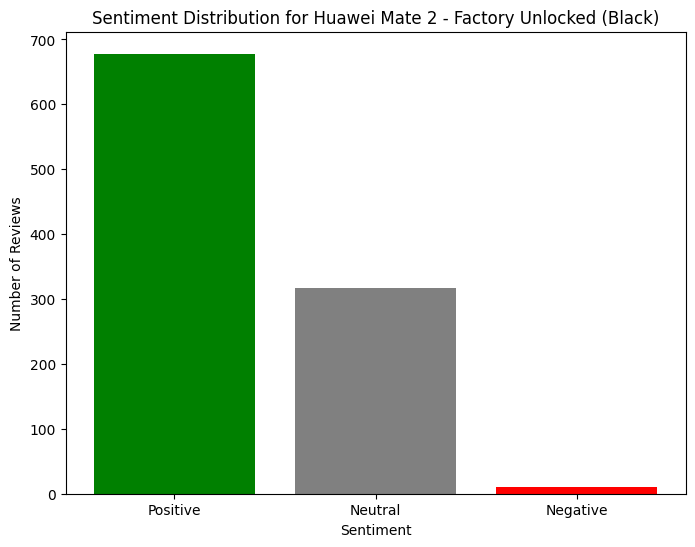

In [5]:
import matplotlib.pyplot as plt

sentiment_counts =product_df["Sentiments"].value_counts()

#to create bar chart
plt.figure(figsize=(8, 6))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'gray', 'red'])

plt.title(f"Sentiment Distribution for {pName}")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [6]:
#  selecting one example review from each category
positive_reviews = product_df[product_df['Sentiments'] == 'Positive'].head(1)
negative_reviews = product_df[product_df['Sentiments'] == 'Negative'].head(1)
neutral_reviews = product_df[product_df['Sentiments'] == 'Neutral'].head(1)

# showing exapmle of each along with the polarity
print("Positive Reviews:")
for index, row in positive_reviews.iterrows():
    polarity = TextBlob(row['Reviews']).sentiment.polarity
    print(f"Review: {row['Reviews']}\nPolarity: {polarity}\n")

print("\nNegative Reviews:")
for index, row in negative_reviews.iterrows():
    polarity = TextBlob(row['Reviews']).sentiment.polarity
    print(f"Review: {row['Reviews']}\nPolarity: {polarity}\n")

print("\nNeutral Reviews:")
for index, row in neutral_reviews.iterrows():
    polarity = TextBlob(row['Reviews']).sentiment.polarity
    print(f"Review: {row['Reviews']}\nPolarity: {polarity}\n")


Positive Reviews:
Review: Extremely worth every penny. Amazing battery life!
Polarity: 0.525


Negative Reviews:
Review: Do not buy.. Phone was advertised as unlocked. Don't believe it!!!!! Said I could contact Huawei to unlock bootloader. That's false too. Wish I could return and buy a phone with support. Stuck on 4.3 and No OTA in future yet Amazon is still selling this phone knowing some of your apps will never work cause the phone is no longer supported.
Polarity: -0.20000000000000004


Neutral Reviews:
Review: I really like this phone. The only gripe I have is that it does have trouble connecting to wifi from time to time. I just turn airplane mode on and off, and this seems to fix the issue. A minor annoyance for anyone who doesn't use wifi often.
Polarity: -0.0125



In [7]:
def rating_to_sentiment(rating):
#  convert numeric rating to sentiment label
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

#  creating new column representing the true sentiment based on rating
product_df["True_Sentiment"] = product_df["Rating"].apply(rating_to_sentiment)

#  filter reviews where TextBlob sentiment is different from rating sentiment
wrong_classified = product_df[product_df["Sentiments"] != product_df["True_Sentiment"]]

print("Number of misclassified reviews:", wrong_classified.shape[0])
print("\nExamples of misclassified reviews:")

#  Show sample misclassified examples
examples = wrong_classified.head(3)

for index, row in examples.iterrows():
    print("-" * 60)
    print(f"Review: {row['Reviews']}")
    print(f"Rating: {row['Rating']} → True Sentiment: {row['True_Sentiment']}")
    print(f"TextBlob Sentiment: {row['Sentiments']}")

print("\nWhy it might be wrong:\nTextBlob relies only on individual words, while ratings reflect the user's overall experience.")


Number of misclassified reviews: 326

Examples of misclassified reviews:
------------------------------------------------------------
Review: I really like this phone. The only gripe I have is that it does have trouble connecting to wifi from time to time. I just turn airplane mode on and off, and this seems to fix the issue. A minor annoyance for anyone who doesn't use wifi often.
Rating: 4 → True Sentiment: Positive
TextBlob Sentiment: Neutral
------------------------------------------------------------
Review: It is a little big. I would not recommend for most as it does not fit in a pocket. Not the back, or the front, or a shirt pocket. But if you are gonna just drop it into a purse then this phone is great. Lately the trend has been towards these 'phablets' and now they may have gone too far. This phone was for my husband, but after he kept setting it down and wandering off without it, it then became mine.I love it. Great battery life. Lots of options that I am not used to seeing 

In [8]:
negative_reviews = product_df[product_df['True_Sentiment'] == 'Negative']['Reviews']

#  all reviews in one text
text=" ".join(negative_reviews).lower()

#  cleaning text
cleaned = ""
for ch in text:
    if ch.isalpha() or ch == " ":
        cleaned += ch
    else:
        cleaned += " "

words = cleaned.split()

#  stopwords to remove
stopwords = ["the","and","to","a","is","it","for","in","of","this","that",
             "was","with","on","my","but","not","very","too","just","are",]

#  new dictionary (word:freq)
freq = {}

for w in words:
    if w not in stopwords and len(w) > 2:
        if w in freq:
            freq[w] += 1
        else:
            freq[w] = 1


sorted_words = sorted(freq.items(), key=lambda x: x[1], reverse=True)

top_words = sorted_words[:20]

#print(top_words)

#  recommendations based on frequent keywords
recommendations = []

for word, count in top_words:

    if word in ["battery", "charge", "charging"]:
        recommendations.append("Improve battery performance and charging stability.")

    elif word in ["screen", "display", "glass", "touch"]:
        recommendations.append("Improve screen durability and display quality.")

    elif word in ["update", "software", "android", "system"]:
        recommendations.append("Optimize software updates to reduce bugs and improve user experience.")

    elif word in ["camera", "photo"]:
        recommendations.append("Enhance camera performance and image quality.")

    elif word in ["signal", "network"]:
        recommendations.append("Improve network connectivity and signal stability.")

    elif word in ["slow", "lag"]:
        recommendations.append("Improve device performance and reduce system lag.")

recommendations = list(set(recommendations))

print("\nGenerated Recommendations:")
for r in recommendations:
    print("-", r)


Generated Recommendations:
- Improve screen durability and display quality.
- Optimize software updates to reduce bugs and improve user experience.
- Improve battery performance and charging stability.


In [9]:
#  save file
product_df.to_csv("processed_reviews.csv", index=False)

print("DataFrame has been successfully exported to processed_reviews.csv")


DataFrame has been successfully exported to processed_reviews.csv
